# Plotting lat-lon and ZM 

## Control, revert and SST simulation names

In [11]:
### RBN: 18 Aug 2020: Set up panel plots that can selectively plot full field., bias, and run differences. ###

import numpy as np
import xarray as xr
import pandas as pd

from metpy.interpolate import log_interpolate_1d
from metpy.units import units

import matplotlib.pyplot as mp
from matplotlib import cm
from mpl_toolkits.axes_grid1 import AxesGrid
#from mpl_toolkits.basemap import Basemap as bmap
import matplotlib as mpl

import cartopy
import cartopy.crs as ccrs
import cartopy.util as cutil
 
import cartopy.feature as cfeature # Map features
from cartopy.mpl.geoaxes import GeoAxes
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.io.shapereader as shpreader

import glob as glob
from sys import exit

import shapely
import shapely.geometry as sgeom
import warnings
import importlib

#from shapely.errors import ShapelyDeprecationWarning
#warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 

import obs_simulations as obs_sims
import plot_2d_utils as putil


%xmode Minimal   ## Fortran-like error tracebacks (doesn't seem to work though)


/glade/work/rneale/python/miniconda3/envs/neale_monsoon/lib/python3.11/site-packages/IPython/core/magics/basic.py:379: UserWarning: Error changing user exception modes.
Unrecognized mode in FormattedTB: <Minimal   ## fortran-like error tracebacks (doesn't seem to work though)>
Valid modes: ['Plain', 'Context', 'Verbose', 'Minimal']
  warn('Error changing %s exception modes.\n%s' %


In [12]:
from dask.distributed import Client
from ncar_jobqueue import NCARCluster

In [13]:
cluster = NCARCluster(project='P93300642',interface='mgt', job_extra_directives=[])
cluster
cluster.scale(jobs=8)
client = Client(cluster)
client

/glade/work/rneale/python/miniconda3/envs/neale_monsoon/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_monsoon/lib/python3.11/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, Fu

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/34571/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/34571/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.18.206.52:42005,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/34571/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [14]:
# Set up case/data variables

dir_root = '/glade/campaign/cgd/amp/amwg/climo/'
dir_root2 = '/glade/p/cgd/amp/people/hannay/amwg/climo2/'

dir_obs = '/glade/campaign/cgd/amp/amwg/amwg_data/obs_data/'
dir_fig = '/glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/'


ldiff_ctrl = True # Difference compared to the control?
lplot_orog = True
lp3d_if_read_in = False # Plot 3D zonal average if it is read in for another variable.

#seas = np.array(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec','DJF','MAM','JJA','SON']) # If 2 seasons does 2 columns, if 1 does successive rows.
seas = np.array(['JJA'])

var_name = 'PRECT'

pregion = 'IO'




#SST cases
#case_desc =  np.array(['C6','AMdsst','CE2','CE2sst','CE2dsst','CE2csst'])
#case_lname = np.array(['AMIP (monthly)','AMIP (daily)','Coupled','Coupled (monthly)','Coupled (daily)','Coupled (climo.)'])

# Limited SST cases
#case_desc =  np.array(['C6','AMdsst','CE2','CE2sst','C5','CE1'])
#case_lname = np.array(['AMIP (monthly SSTs)','AMIP (daily SSTs)','Coupled','Coupled (monthly SSTs)','CAM5','CESM1'])


# Vres plots
#case_desc =  np.array(['ERAI','CE3.79','CE3.80','CE2.1850','CE1.1850','CC4.1850'])
#case_lname = np.array(['ERAI','CE3.79','CE3.80','CE2.1850','CE1.1850','CC4.1850'])

#case_desc =  np.array(['TRMM','CE3.78b','CE3.81b','CE3.82b','CE3.83b','CE3.90b'])

#case_desc =  np.array(['TRMM','CE2','CE3.90b','CE3.98','CE3.104','CE3.112'])
#case_lname = np.array(['TRMM','CE2','CE3.90b','CE3.98','CE3.104','CE3.112'])

case_desc =  np.array(['TRMM','GPCP','CAM7-L32','CAM67-L58','CAM7-L93','CAM7-L32'])
case_lname = np.array(['TRMM','GPCP','CAM7-L32','CAM67-L58','CAM7-L93','CAM7-L32'])



lcase_lname = True

# Available obs sources for file access.
obs_source = ['GPCP','TRMM','ERAI','ERS','MERRA']





###################

nrow = 2 ; ncol = 3 # Rows and columns

# #of contour intervals
ncint = 20 ; ancint = 20

# Domainfig

#if seas[0]=='JJA':
#    lat_min = -20 ; lat_max = 40
#    lon_min = 180-320. ; lon_max = 180-220.
#    lon_min = 0 ; lon_max = 160
    
#    lat_min = -10 ; lat_max = 30
#    lon_min = 20 ; lon_max = 70

#    shapename = 'admin_1_states_provinces_lakes_shp'
#    states_shp = shpreader.natural_earth(resolution='110m',
#                                         category='cultural', name=shapename)

#if seas[0] in ['MAM','JJA','Mar']:

#tlon_min = lon_min
#tlon_max = lon_max


match pregion:

    case 'IO':
        ''' Indian Ocean '''
        lat_min = -10 ; lat_max = 35
        lon_min = 50 ; lon_max = 120
        plev_scale = 1.
        aplev_scale = 1.
        
        rlon_min = lon_min
        rlon_max = lon_max


    case 'US':
        ''' USA '''
        lat_min = 25 ; lat_max = 55
        lon_min = -120 ; lon_max = -70 
        plev_scale = 0.25
        aplev_scale = 0.25

        rlon_min = 360+lon_min
        rlon_max = 360+lon_max

    case 'SAm':
        ''' South America '''
        lat_min = -40 ; lat_max = 15
        lon_min = -90 ; lon_max = -30 
        plev_scale = 0.5
        aplev_scale = 0.5

        rlon_min = 360.+lon_min
        rlon_max = 360.+lon_max



    case 'Aus':
        ''' Australia '''
        lat_min = -20 ; lat_max = 10
        lon_min = 120 ; lon_max = 150
        plev_scale = 0.5
        aplev_scale = 0.5

        rlon_min = lon_min
        rlon_max = lon_max

    case 'TP':
        lat_min = -20 ; lat_max = 20
        lon_min = 0 ; lon_max = 359.
        plev_scale = 0.5
        aplev_scale = 0.5

        rlon_min = lon_min
        rlon_max = lon_max

        tlon_min = lon_min 
        tlon_max = lon_max 

    
        nrow = 3 ; ncol = 2 # Rows and columns
            


#if seas[0]=='DJF':
#    lat_min = -20 ; lat_max = 20
#    lon_min = 90 ; lon_max = 170

#    lat_min = -30 ; lat_max = 10
#    lon_min = 0 ; lon_max = 50
    
#    lat_min = -20 ; lat_max = 10
#    lon_min = -100 ; lon_max = -40

   
    
lon_ave_w = 120. ; lon_ave_e = 160.

## Variable, Case, Season and Plot Type Options

<p style="color:violet;">Case and Variable Options, with Attributes

In [15]:
# List of variable info.

pvars = {}

pvars['PRECT']  = ['Precipitation','mm/day','2d','x','x',
    86400.*1000,1.,2.,20.,-2.,2.,'terrain_r','PRGn']
pvars['LHFLX']  = ['Surface Latent Heat Flux','W/m^2','2d','x','x',
    1,1.,100.,300.,-100.,100.,'PuBuGn','PRGn']
pvars['SWCF']   = ['Short Wave Cloud Forcing','W/m^2','2d','x','x',
    1.,1.,-100,-10.,-50.,50.,'Purples','RdBu_r']
pvars['LWCF']   = ['Long Wave Cloud Forcing','W/m^2','2d','x','x',
    1.,1.,10.,85.,-30.,30.,'Reds','RdBu_r']
pvars['CLDTOT'] = ['Total Cloud','%','2d','x','x',
    100.,1.,0,100.,-30.,30.,'PuBuGn','PRGn']
pvars['CLDLOW'] = ['Total Cloud','%','2d','x','x',
    100.,1.,0,100.,-30.,30.,'PuBuGn','PRGn']
pvars['TMQ']  = ['Precipitable Water','mm','2d','x','x',
    1,1.,0.,60.,-8.,8.,'terrain_r','PRGn']


pvars['T800']   = ['800-mb Temperature','m/s','3d','T',800.,
    1.,1.,0,100.,-30.,30.,'PuBuGn','PRGn']
pvars['Z500']   = ['500-mb Geopotential Height','m','3d','Z3',500.,
    1.,1.,0,100.,-30.,30.,'PuBuGn','PRGn']

pvars['U200']   = ['200-mb Zonal Wind','m/s','3d','U',200.,
    1.,1.,-20,80.,-10.,10.,'PuBuGn','PRGn']
pvars['U850']   = ['850-mb Zonal Wind','m/s','3d','U',850.,
    1.,1.,-40,40.,-10.,10.,'PRGn','PRGn']

pvars['U10']    = ['10-m Wind Speed','m/s','2d','x','x',
    1.,1.,0,10.,-5.,5.,'PuBuGn','PRGn']
pvars['TAUX']    = ['Surface Zonal Stress','m/s','2d','x','x',
    -1.,1.,-0.15,0.15,-0.1,0.1,'PRGn','PRGn']

pvars['AODVIS']    = ['Aeorosol Optical Depth','m','2d','x','x',
    1.,1.,0.,1.5,-0.5,0.5,'terrain_r','PRGn']

P0 = 100000.

## Prefix letters for figures.
fig_let = np.array(['(a) ','(b) ','(c) ','(d) ','(e) ','(f) ','(g) ','(h) ','(i) ','(j) ','(k) ','(l) ','(m) '])


## Season arrays 
seas_names = np.array(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

## Determine if 3D fields are required from the climo. files

In [16]:
pvars_df = pd.DataFrame.from_dict(pvars, orient='index',columns=['long name','munits','dim_num','3d_var','pres_lev','mscale','oscale','cmin','cmax','acmin','acmax','cmap','acmap'])
print(pvars_df)

var_name_in = var_name # Could ultimately be different from var_name as 3D variable might be required. 

### Do we need to find a p-level variable from 
# list out keys and values separately 

dim_var_file = pvars_df.loc[var_name]['dim_num'] 

l3d_var = True if '3d' in dim_var_file else False

#### Construct 2D pressure field from 3d history file field ##
if l3d_var:    
    var_name_in = pvars_df.loc[var_name]['3d_var'] # Which 3D variable is need for this field? 
    plev_val = pvars_df.loc[var_name]['pres_lev']
    print('** ',var_name,' will be calculated from 3d variable ',var_name_in,' **')    
    
else :
    print('** ',var_name,' available on history file, no pressure interpolation required **')
    lp3d_if_read_in = False # Cannot plot the 3D field
    
    


                         long name  munits dim_num 3d_var pres_lev  \
PRECT                Precipitation  mm/day      2d      x        x   
LHFLX     Surface Latent Heat Flux   W/m^2      2d      x        x   
SWCF      Short Wave Cloud Forcing   W/m^2      2d      x        x   
LWCF       Long Wave Cloud Forcing   W/m^2      2d      x        x   
CLDTOT                 Total Cloud       %      2d      x        x   
CLDLOW                 Total Cloud       %      2d      x        x   
TMQ             Precipitable Water      mm      2d      x        x   
T800            800-mb Temperature     m/s      3d      T    800.0   
Z500    500-mb Geopotential Height       m      3d     Z3    500.0   
U200             200-mb Zonal Wind     m/s      3d      U    200.0   
U850             850-mb Zonal Wind     m/s      3d      U    850.0   
U10                10-m Wind Speed     m/s      2d      x        x   
TAUX          Surface Zonal Stress     m/s      2d      x        x   
AODVIS      Aeorosol

## Main Plotting Loop

+++++ Plotting +++++ PRECT
# cases =  6
++++ SEASON =  JJA
++ Overplotting Orography ++
/glade/campaign/cgd/amp/amwg/climo/


IndexError: list index out of range

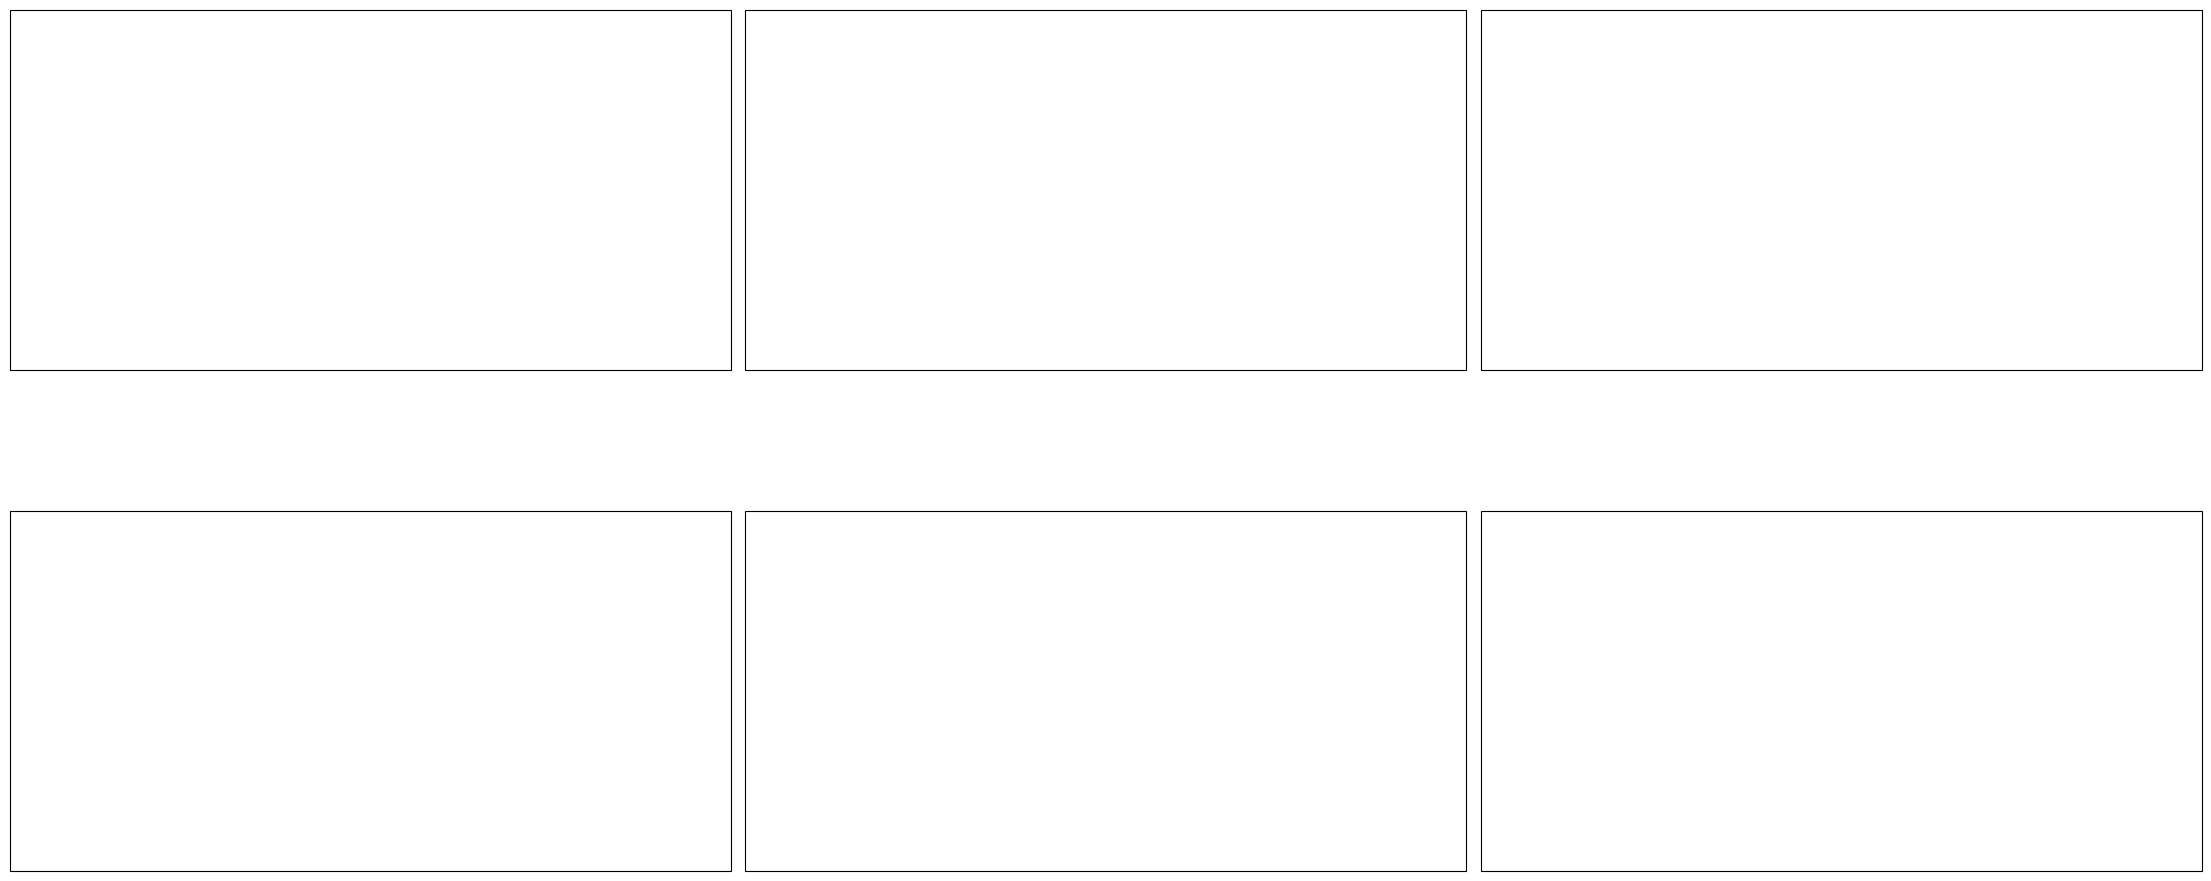

In [17]:
#Import case definitions list
importlib.reload(obs_sims)
importlib.reload(putil)

# Grab sims df
cases_df = obs_sims.cam_revert_list()

# Check #case and plot spaces.
ncases = case_desc.size
nplots = nrow * ncol

if ncases > nplots:
    print("")
    print("*** nrow*ncol does not math ncases - exiting ***")
    exit("nplot,ncase mi-match")

########## SET UP LAT LON PLOTS ##############

nseas = seas.size  # Different for different seasons

if nseas == 1:
    axes_pad = 0.4
    share_all = False
    cbar_location = "right"
    cbar_mode = "each"
    cbar_pad = 0.02
    cbar_size = "2%"
else:
    axes_pad = 0.1
    share_all = False
    cbar_location = "right"
    cbar_mode = "edge"
    cbar_pad = 0.02
    cbar_size = "2%"


# Grab/Process data
mscale = pvars_df.loc[var_name]["mscale"]
lname = pvars_df.loc[var_name]["long name"]
vunits = pvars_df.loc[var_name]["munits"]
# Set up graphics
# pproj = ccrs.Mollweide(central_longitude=0.0)
pproj = ccrs.PlateCarree()
#tpproj = ccrs.PlateCarree()
tpproj = ccrs.PlateCarree(central_longitude=180.)
#tpproj = ccrs.EckertV(central_longitude=180.)




# lat,lon Contouring choices #

# mp.close()

cmin = pvars_df.loc[var_name]["cmin"]
cmax = pvars_df.loc[var_name]["cmax"]
acmin = pvars_df.loc[var_name]["acmin"]
acmax = pvars_df.loc[var_name]["acmax"]

dcont = (cmax - cmin) / ncint
adcont = (acmax - acmin) / ancint

plevels = np.arange(cmin, cmax + dcont, dcont, dtype=float)
aplevels = np.arange(acmin, acmax + adcont, adcont, dtype=float)

if var_name == "PRECT":
    #    plevels = np.array([1,2,3,4,5,8,10,12,15,20,25,30])
    plevels = np.array([1, 2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 20])
    aplevels = np.array([-12, -8, -6, -4, -3, -2, -1, 0, 1, 2, 3, 4, 6, 8, 10, 12])

    plevels = np.array([ip*plev_scale for ip in plevels])
    aplevels = np.array([ip*aplev_scale for ip in aplevels])

if var_name == "AODVIS":
    plevels = np.array([0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 2.5])
    aplevels = np.array(
        [-1.0, -0.5, -0.2, -0.1, -0.05, -0.025, -0.01, -0.005, 0.0, 0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1.0,] )





############### SETUP ZONAL AVERAGE PLOTS ################

if lp3d_if_read_in:
    axzm_zm, axs_zm = mp.subplots(nrows=nrow, ncols=ncol, figsize=[16, 10])

# These array counters are just for the ax of the zm plots.
irow = np.zeros((nplots), dtype=int)
icol = np.zeros((nplots), dtype=int)

for ii in range(0, nrow):
    irow[ii * ncol : ii * ncol + ncol] = ii
for ij in range(0, nrow):
    icol[ij * ncol : ij * ncol + ncol] = np.arange(0, ncol, 1)

#### PLOTTING ###

print("+++++ Plotting +++++ " + var_name)
print("# cases = ", ncases)

pvar_ctrl = None


##

orog_file = "/glade/campaign/cesm/cesmdata/cseg/inputdata/atm/cam/topo/USGS_gtopo30_0.23x0.31_remap_c061107.nc"
orog_ds = xr.open_dataset(orog_file, engine="netcdf4")
orog = 0.1 * orog_ds["PHIS"]


###################################
#### LOOP Cases and Subfigures ####
###################################


for iseas, this_seas in enumerate(seas):

    pvar3d_ctrl = None
    pvar_ctrl = None


    fig, axs = mp.subplots(
    nrows=nrow,
    ncols=ncol,
    constrained_layout=True,
    subplot_kw={"projection": tpproj},
    figsize=(22, 10),
    )

    fig.patch.set_facecolor("white")  # White not transparent background
    
    if this_seas in seas_names:
        this_fseas = str(np.where(seas_names == this_seas)[0][0] + 1).zfill(
            2
        )  # File name of seasaon e.j., 01,02,ANN etc.
    else:
        this_fseas = this_seas  # Same name for seasons

    if nseas == 1:
        isub0 = 0
        isub1 = ncases
        isub_step = 1
    else:
        isub0 = iseas
        isub1 = 2 * ncases + iseas - nseas + 2
        isub_step = nseas

    iplots = np.arange(isub0, isub1, isub_step)





    
    print("++++ SEASON = ", seas[iseas])
    if lplot_orog: print("++ Overplotting Orography ++")

    axs = axs.flatten()
    for icase, ax in enumerate(axs):
        pvar = None  # Reset

        cdesc = case_desc[icase]
   
        
        cname = cases_df.loc[cdesc]["run name"]
        mscale = pvars_df.loc[var_name]["mscale"]
        oscale = pvars_df.loc[var_name]["oscale"]

        izm = irow[icase]
        jzm = icol[icase]  # Paneling indices

        file_in = None
        
        if cdesc == "CE2":
            file_in = (
                dir_root
                + cname
                + "/yrs_1979-2005/"
                + cname
                + "_"
                + this_fseas
                + "_climo.nc"
            )
        
        if cdesc in ["L58zm2new"]:
            files_star = (
                dir_root
                + cname
                + "/"
                + cname
                + "*/"
                + cname
                + "*_"
                + this_fseas
                + "_climo.nc"
            )
            print(files_star)
            file_in = glob.glob(files_star)[0]
            print(file_in)


        # CESM3 timeseries climo files.
        if 'CE3' in desc or 'CAM7' in cdesc:
            print(dir_root)
            file_in = glob.glob(dir_root+cname+'/*/'+cname+'_'+var_name+'_climo.nc')[0]

        # Any remaining files    
        if file_in == None:
            file_in = (
                dir_root
                + cname
                + "/0.9x1.25/"
                + cname
                + "_"
                + this_fseas
                + "_climo.nc"
            )

        if cdesc in obs_source:
            file_in = dir_obs + cname + "_" + this_fseas + "_climo.nc"

        print("")
        print("Case ", (icase + 1), " of ", ncases, " -> " + cdesc + " - " + cname)
        print("-File = " + file_in)
        print("")


        
        ## Read in variable data ##

        if 'CE3' in cdesc:   # CE3 ADF single file per variable format climo output 
            case_nc = xr.open_dataset(file_in, engine="netcdf4")
            mon_index = putil.get_indexes(seas[0])
 
            case_nc = case_nc.sel(time=mon_index).mean(dim='time').squeeze()

            # Calculate the weight for each month based on the number of days
#            weights = seas_data.time.dt.days_in_month / seas_data.time.dt.days_in_month.sum()

            # Calculate the weighted mean along the time dimension
#            case_nc = (seas_data * weights).sum(dim='time')


            
        else:  # Old climo outpudt data
            case_nc = xr.open_dataset(file_in, engine="netcdf4", decode_times=False)
            # Composite variables #
            if var_name == "PRECT":
                if cdesc in ["TRMM", "GPCP"]:
                    pvar = case_nc["PRECT"]
                    pvar = pvar.squeeze()
                    pvar = oscale*pvar
                else:
                    pvar = case_nc["PRECC"].squeeze() + case_nc["PRECL"].squeeze()

        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        # Interpolated from 3D variable #

        if l3d_var:
            print("++ Interpolating from 3D field ##")
            pvar3d = case_nc[var_name_in].squeeze()  # Read in 3D variable
            #        pvar3d = units.Quantity(case_nc[var_name_in])
            pvar3d.squeeze()

            print("")
            pres_levu = plev_val * units.hPa  # Set interpolation level (in hPa)
            
            
            # Read in vars required for interpolation and 3D pressure values
            ps, hyam, hybm = (
                case_nc["PS"].squeeze(),
                case_nc["hyam"],
                case_nc["hybm"],
            )

            pres_lev = pvar3d.copy(deep=True)  # Make meta copy from the 3d variable
            pres_lev = hyam * P0 + hybm * ps  # Change values to 3D pressure.
            pres_lev = units.Quantity(pres_lev, "Pa")  # Attach metpy units

            # Perform vertical interpolation

            pvar = ps.copy(deep=True)  # Copy off meta data from the 2D PS field.

            pvar = log_interpolate_1d(
                pres_levu, pres_lev, pvar3d, axis=0
            )  # Annoying as all the meta data is lost.
            pvar = pvar.squeeze()
            pvar = xr.DataArray(
                pvar, coords=[pvar3d.lat, pvar3d.lon], dims=["lat", "lon"]
            )

            # Save off mean/ctrl
            if pvar3d_ctrl is None:
                pvar3d_ctrl = pvar3d

            if icase > 0 and ldiff_ctrl:
                pvar3d = np.subtract(pvar3d, pvar3d_ctrl)
                pvar3d = (
                    pvar3d.interp(lat=pvar3d_ctrl.lat, lon=pvar3d_ctrl.lon)
                    if cdesc == "C5"
                    else pvar3d
                )
















        
        # Standard 2D variable read.
        if pvar is None:
            pvar = case_nc[var_name_in].squeeze()

        # Only scale the model data.
        if cdesc in obs_source:
            pvar = oscale * pvar  # Scale to obs. units.
        else:
            pvar = mscale * pvar  # Scale to modle. units.

        
        lon = case_nc["lon"]
        lat = case_nc["lat"]

        ## Retain control case data ##
        if pvar_ctrl is None:
            pvar_ctrl = pvar

        ## Contouring (full or anom) ##

        clevels = plevels
        levs_4colbar = clevels

        cmap = pvars_df.loc[var_name]["cmap"]

        extend = 'both'
        
        ## Modify if anom plot ##

        rmse_text = ''
        
        if icase > 0 and ldiff_ctrl:
            # I think CAM5 coords are slighly misalligned so have to interpolate to the pvar_ctrl (mostly CAM6/C6)
            print('Interpolate for difference plots...')
            pvar = pvar.interp(lat=pvar_ctrl.lat, lon=pvar_ctrl.lon)

            pvar = np.subtract(pvar, pvar_ctrl)
            print('Done...')
            
            levs_4colbar = aplevels

            cmap = pvars_df.loc[var_name]["acmap"]

            extend = 'both'

            pvar_rmse = pvar.sel(lat=slice(lat_min, lat_max), lon=slice(rlon_min, rlon_max))
         
            rmse = np.sqrt((pvar_rmse ** 2).mean())

            rmse_text = f' [RMSE: {rmse:.4f}]'
            
#            ax.text(tlon_min, lat_min, f'RMSE: {rmse:.4f}',ha='left', va='bottom',fontsize=15, bbox=dict(facecolor='white', alpha=0.8))

            


        clevels = levs_4colbar[ abs(levs_4colbar) > 1.0e-15 ]  # Remove zero contour, but sometimes it can be very small as well.
      

        ## Plotting for each ax ##
        # Domain, this seems flakey for cartopy ##
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=pproj)
        ax.coastlines(linewidth=2)
        ax.gridlines()
        ax.add_feature(cartopy.feature.LAND, zorder=0)
        ax.add_feature(cfeature.BORDERS)

        # Add U.S. states
        if pregion == 'US': ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='black')
        
        ax.set_yticks(np.arange(lat_min, lat_max + 10.0, 10.0), crs=pproj)
        lat_formatter = LatitudeFormatter()
        ax.yaxis.set_major_formatter(lat_formatter)

        ax.set_xticks(np.arange(lon_min, lon_max + 10.0, 10.0), crs=pproj)
        lon_formatter = LongitudeFormatter()
        ax.xaxis.set_major_formatter(lon_formatter)

        ax.set_title(fig_let[icase]+cdesc + rmse_text)
        
        ## Add Cyclic Point ##

        #        print(pvar.lon)
        #        pvarc,lonc = cutil.add_cyclic_point(pvar,coord=pvar.lon)
        pvarc = pvar
        lonc = pvar.lon
        lat = pvar.lat
        #        print(pvarc)

        ## Translate to -180->+180 - maddening

        #        ilon_pivot = int(lon.size/2)+1
        #        pvarc = np.roll(pvarc, ilon_pivot, axis=1) # 144 points will roll you from 0-360 ->-180-180 data

        ## CONTOUR PLOT (normalize colorbar for non-linear intervals) ##
        
        norm = cm.colors.BoundaryNorm(boundaries=levs_4colbar, ncolors=256)
        pplot = ax.contourf(
            lonc, lat, pvarc, transform=pproj, cmap=cmap, extend=extend, levels=clevels
        )
    
        if icase == 0:
            cbax = ax.inset_axes([1.05, 0.2, 0.05, 0.8], transform=ax.transAxes)
            cbar = fig.colorbar(pplot, cax=cbax, orientation="vertical")
        if icase == 1 & ldiff_ctrl:
            cbax = ax.inset_axes([1.05, 0.2, 0.05, 0.8], transform=ax.transAxes)
            cbar = fig.colorbar(pplot, cax=cbax, orientation="vertical")
        
        #            cbar1 = mp.colorbar(pplot, ax=ax, orientation='vertical')

        #### COLORBARS - Don't need one on every figure. #####

        #        cbar = mp.colorbar(pplot,shrink=0.75) # Plot individual color bars before line c_ screws it up!
        #        cbar.ax.tick_params(labelsize=20)

        #        pplot = mpl.colorbar.ColorbarBase(ax=ax, ticks=levs_4colbar[::2], # Every other tick.
        #            cmap=cmap,boundaries=levs_4colbar,orientation='vertical',norm=norm)
        ax.tick_params(labelsize=15)

        if ldiff_ctrl:  # Make sure smallest contour intervals are white
            pplot = ax.contourf(
                lonc,
                lat,
                pvarc,
                levels=[-min(abs(clevels)), min(abs(clevels))],
                colors="w",
                transform=pproj 
                )

        ### Remove the colorbar entirely for these panels (just need two, 1 for full and 1 for anoms)
        #        if icase in np.arange(1,ncases,1) and iseas==nseas-1:
        #            pplot = mpl.colorbar.ColorbarBase(ax=ax).remove()
        #            cbar.remove()
        #           mp.subplots_adjust(right=0.9)
        
        #### LINE PLOT  ####
        lpplot = ax.contour(lonc,lat, pvarc,transform=pproj,levels=clevels,colors="black",linewidths=0.5)
        
        
        del lonc
        del pvarc
        
        #### Orography?
        if lplot_orog:
           
            pplot = ax.contour(orog.lon, orog.lat, 0.1 * orog, transform=pproj, levels=[100, 200, 400, 600, 800, 1000],  colors="red")
        

#        if iseas >= 0:
#            cdesc_fig = cdesc if not lcase_lname else case_lname[icase]
#            ax.text(tlon_min + 2, lat_max - 1., fig_let[icase] + cdesc_fig, fontsize=20, fontweight="bold", backgroundcolor="white", zorder=10)

        #### CONTOUR LABELING ####

        #        mp.clabel(ax,
        #            colors=['black'],
        #            fontsize=8,
        #            manual=False,  # Automatic placement vs manual placement.
        #            inline=False,  # Cut the line where the label will be placed.
        #            fmt=' {:.0f} '.format,  # Labels as integers, with some extra space.
        #        )

        ## ZM PLOTS ##

        if lp3d_if_read_in:
            pvar_zm = pvar3d.loc[:, lat_min:lat_max, lon_ave_w:lon_ave_e].mean(dim="lon")  # Calc. zonal average
            lat_p = lat.loc[lat_min:lat_max]

            #            print(axs_zm[izm,jzm].__dict__)
            if izm == nrow - 1:
                axs_zm[izm, jzm].set_xlabel("Latitude", fontsize=8)
            if jzm == 0:
                axs_zm[izm, jzm].set_ylabel("Pressure (mb)", fontsize=8)

            axs_zm[izm, jzm].set_xticks(np.linspace(-90, 90, 7))

            axs_zm[izm, jzm].set_title(
                fig_let[icase] + cdesc,
                x=0.72,
                y=0.02,
                fontweight="bold",
                fontsize=10,
                horizontalalignment="left",
                backgroundcolor="white")

            zm_plot = axs_zm[izm, jzm].contourf(
                lat_p, pvar_zm.lev, pvar_zm, levels=clevels, cmap=cmap, extend="both")

            fig_zm.colorbar(
                zm_plot, ax=axs_zm[izm, jzm], ticks=levs_4colbar[::2], pad=0.01)

            axs_zm[izm, jzm].tick_params(labelsize=8)  # Change axis values font height.
            # Contouring
            zm_plot = axs_zm[izm, jzm].contourf(
                lat_p, pvar_zm.lev, pvar_zm, levels=[-1, 1], colors="w")
            zm_plot = axs_zm[izm, jzm].contour(
                lat_p,
                pvar_zm.lev,
                pvar_zm,
                colors="black",
                linewidths=1.0,
                levels=clevels)

            axs_zm[izm, jzm].invert_yaxis()
            axs_zm[izm, jzm].set_ylim([1000.0, 50.0])

            ## Contour labeling ##

            ax.clabel(
                zm_plot,  # Typically best results when labelling line contours.
                colors=["black"],
                fontsize=10,
                manual=False,  # Automatic placement orogvs manual placement.
                inline=True)  # Cut the line where the label will be plot
              # Labels as lp3d, with some extra space.

    #  Output figure

    #    mp.subplots_adjust(wspace = .001)
    fig.suptitle(lname + " (" + vunits + ") - " + this_seas, fontsize=40)

    #    cbar_ax = fig.add_axes([1.0, 0.2, 0.01, 0.6])
    #    mp.colorbar(pplot, ax=axs, cax=cbar_ax,location='right', shrink=0.6)

    #    pplot = mp.colorbar(pplot, cax=cbar_ax, orientation="vertical")
    #    pplot = cbar_ax.tick_params(labelsize=30)
    #    mp.tight_layout()

    
    mp.tight_layout()

    diff_png = '_bias' if ldiff_ctrl else ''
    
    if nseas == 1:
        mp.savefig(dir_fig + "AGU24_dev_" + pregion + "_" + var_name + "_" + seas[0] + diff_png +".png", dpi=80, bbox_inches="tight")
    else:
        mp.savefig(dir_fig + 'CESM3_1850_baseline_USA_' + var_name + '_' +seas[iseas]+ diff_png +'.png', dpi=80, bbox_inches="tight")

    
    mp.show()   
        
#    del pplot ; del lpplot 


# if l3d_var:
#    mp.savefig('CAM6_oview_zm_'+var_name_in+'_'+seas+'.png', dpi=300, bbox_inches='tight')